# 01 · Data Understanding

In this notebook I explore every raw dataset of the HAB risk project, one at a time, using the **same template** for each:

1. Source and description
2. Structure (shape, types, first rows, long vs wide)
3. Profile table
4. Time coverage (records per month)
5. Spatial coverage (map with the Sarasota box)
6. Value checks (units, impossible values, sentinels, QC flags)
7. Duplicates
8. Findings and decisions

At the end of the notebook:
- the **summary table** of all datasets (saved to `docs/data_summary.csv`)
- the **coverage timeline** (one row per dataset)
- the **satellite chlorophyll comparison** (why we keep dataset 7A)
- the **data-issues log** (saved to `docs/data_issues.csv` and `docs/data_issues.md`)

**Before running:** all raw files must be in the Google Drive folder `MyDrive/biointerphase_data`.

## Setup

In [3]:
# Libraries used in this notebook
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
# Mount Google Drive so we can read the data files
from google.colab import drive
drive.mount('/content/drive')

# Folder in Drive that holds all the raw data files
DATA = '/content/drive/MyDrive/biointerphase_data'

# Folder where this notebook saves its tables
DOCS = os.path.join(DATA, 'docs')
os.makedirs(DOCS, exist_ok=True)

print(os.listdir(DATA))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.gitkeep', 'MoteMarine_BottomTemp.csv', 'bradentonFL_tempData.csv', 'florida_cyanotoxins_2015-01-01_to_2026-06-17.csv', 'habsos_cellcounts.csv', 'Chlorophyll_subset_sarasota_2018_2026.nc', 'Sarasota_Wind&Temp.csv', 'SarasotaWindData.csv', 'NutrientsFL_2006_2025.csv', 'docs']


In [5]:
# Sarasota study box (latitude and longitude limits)
LAT_MIN, LAT_MAX = 26.5, 28.0
LON_MIN, LON_MAX = -83.5, -81.8


def profile(df):
    """Summary of every column: type, % missing, number of unique values, min and max."""
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'pct_missing': (df.isna().mean() * 100).round(1),
        'n_unique': df.nunique(),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
    })


def plot_monthly_counts(dates, title):
    """Bar chart of records per month, so gaps in the data are easy to see."""
    counts = dates.dt.to_period('M').value_counts().sort_index()

    plt.figure(figsize=(12, 3))
    plt.bar(counts.index.to_timestamp(), counts.values, width=25)
    plt.title(title)
    plt.ylabel('Records per month')
    plt.show()


def draw_box(ax):
    """Draw the Sarasota study box as a red rectangle."""
    ax.plot([LON_MIN, LON_MAX, LON_MAX, LON_MIN, LON_MIN],
            [LAT_MIN, LAT_MIN, LAT_MAX, LAT_MAX, LAT_MIN],
            color='red', label='Sarasota box')


def plot_points(lat, lon, title):
    """Scatter plot of sample locations with the study box drawn on top."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(lon, lat, s=2, alpha=0.3)
    draw_box(ax)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend()
    plt.show()


def in_box(lat, lon):
    """True for points inside the Sarasota study box."""
    return lat.between(LAT_MIN, LAT_MAX) & lon.between(LON_MIN, LON_MAX)

---
## 1. HABSOS cell counts (target)

**Source:** NOAA NCEI, Harmful Algal BloomS Observing System (HABSOS) — https://www.ncei.noaa.gov/products/harmful-algal-blooms-observing-system

**One row =** one water sample tested for *Karenia brevis*: location, date, depth, cell count (cells/L) and the FWC category.

**Scope:** Gulf coast (FL, TX, AL, MS), 1953 → 2026, irregular sampling. Wide format.

**Role:** this is our **target**. The bloom label comes from `CELLCOUNT`.

In [6]:
habsos = pd.read_csv(os.path.join(DATA, 'habsos_cellcounts.csv'), low_memory=False)
habsos['SAMPLE_DATE'] = pd.to_datetime(habsos['SAMPLE_DATE'])

print('Shape:', habsos.shape)
habsos.head()

Shape: (219152, 26)


,OBJECTID,DESCRIPTION,LATITUDE,LONGITUDE,STATE_ID,SAMPLE_DATE,SAMPLE_DEPTH,GENUS,SPECIES,CATEGORY,...,WATER_TEMP,WATER_TEMP_UNIT,WATER_TEMP_QA,WIND_DIR,WIND_DIR_UNIT,WIND_DIR_QA,WIND_SPEED,WIND_SPEED_UNIT,WIND_SPEED_QA,QA_COMMENT
0,1,Tom Adams Bridge (Lemon Bay),26.93450,-82.3535,FL,1953-08-19,0.5,Karenia,brevis,medium,...,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
1,2,Naples Pier,26.13163,-81.8063,FL,1953-08-26,0.5,Karenia,brevis,not observed,...,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
2,3,Piney Point; Lee County,26.53340,-81.9796,FL,1953-08-26,0.5,Karenia,brevis,not observed,...,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
3,4,Cortez Bridge,27.46840,-82.6937,FL,1953-08-26,0.5,Karenia,brevis,medium,...,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
4,5,Sarasota Bay; 3 mi North of bridge,27.37750,-82.5708,FL,1953-09-03,0.5,Karenia,brevis,high,...,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day


In [7]:
profile(habsos)

,dtype,pct_missing,n_unique,min,max
CATEGORY,object,0.4,5,NaN,NaN
CELLCOUNT,float64,0.0,6139,0.00000,7.688900e+09
CELLCOUNT_QA,int64,0.0,2,1.00000,5.000000e+00
CELLCOUNT_UNIT,object,0.0,1,NaN,NaN
DESCRIPTION,object,1.4,29889,NaN,NaN
GENUS,object,0.0,1,NaN,NaN
LATITUDE,float64,0.0,30478,24.00000,3.071490e+01
LONGITUDE,float64,0.0,30061,-97.66535,-7.827890e+01
OBJECTID,int64,0.0,219152,1.00000,6.188790e+05
QA_COMMENT,object,76.1,101,NaN,NaN


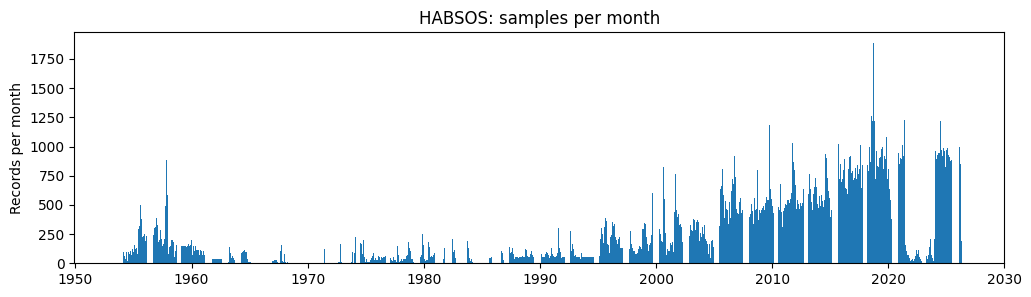

,count
SAMPLE_DATE,
2015,7403
2016,9195
2017,9472
2018,12200
2019,10823
2020,8544
2021,6282
2022,639
2023,800


In [8]:
# Time coverage
plot_monthly_counts(habsos['SAMPLE_DATE'], 'HABSOS: samples per month')

# Samples per year since 2015 (look at 2022 and 2023)
habsos['SAMPLE_DATE'].dt.year.value_counts().sort_index().loc[2015:]

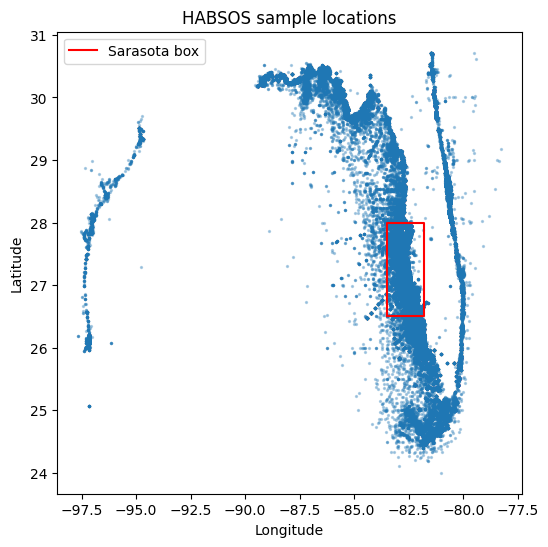

STATE_ID
FL    211838
TX      3139
AL      3125
MS      1050
Name: count, dtype: int64
Unique lat/lon points: 37507
Samples inside the Sarasota box: 120489


In [9]:
# Spatial coverage
plot_points(habsos['LATITUDE'], habsos['LONGITUDE'], 'HABSOS sample locations')

print(habsos['STATE_ID'].value_counts())
print('Unique lat/lon points:', habsos[['LATITUDE', 'LONGITUDE']].drop_duplicates().shape[0])
print('Samples inside the Sarasota box:', in_box(habsos['LATITUDE'], habsos['LONGITUDE']).sum())

In [10]:
# Value checks

# Category counts (NaN = missing category, we will recompute it from CELLCOUNT)
print(habsos['CATEGORY'].value_counts(dropna=False), '\n')

# Cell-count range inside each category (these are the FWC thresholds)
print(habsos.groupby('CATEGORY')['CELLCOUNT'].agg(['min', 'max']), '\n')

# Physically impossible values
print('Water temp > 40 C:', (habsos['WATER_TEMP'] > 40).sum(), '| max =', habsos['WATER_TEMP'].max())
print('Salinity > 45 ppt:', (habsos['SALINITY'] > 45).sum(), '| max =', habsos['SALINITY'].max())
print('Sample depth > 2 m:', (habsos['SAMPLE_DEPTH'] > 2).sum(), '| max =', habsos['SAMPLE_DEPTH'].max())

# Wind columns are almost empty
print('Wind speed missing (%):', round(habsos['WIND_SPEED'].isna().mean() * 100, 1))

# Timestamps at exactly midnight usually mean the time of day is unknown
midnight = (habsos['SAMPLE_DATE'].dt.hour == 0) & (habsos['SAMPLE_DATE'].dt.minute == 0)
print('Timestamps at 00:00 (%):', round(midnight.mean() * 100, 1))

CATEGORY
not observed    172626
very low         18778
low              12226
medium           11207
high              3459
NaN                856
Name: count, dtype: int64 

                    min           max
CATEGORY                             
high          1000000.0  7.688900e+09
low             10000.0  9.989600e+04
medium         100000.0  9.990000e+05
not observed        0.0  0.000000e+00
very low            1.0  9.733000e+03 

Water temp > 40 C: 4 | max = 1503.88888889
Salinity > 45 ppt: 48 | max = 308.0
Sample depth > 2 m: 24143 | max = 1000.3
Wind speed missing (%): 99.9
Timestamps at 00:00 (%): 22.2


In [11]:
# Duplicates

# Exact duplicates (ignore OBJECTID because it is just a row number)
habsos_no_id = habsos.drop(columns='OBJECTID')
print('Exact duplicates:', habsos_no_id.duplicated().sum())

# Same place, time and depth, but different values (conflicting duplicates)
key = ['LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_DEPTH']
print('Conflicting duplicates:', habsos_no_id.drop_duplicates().duplicated(subset=key).sum())

Exact duplicates: 1542
Conflicting duplicates: 1009


### Findings and decisions: HABSOS
- **2022–2023 are nearly empty** (hundreds of rows vs thousands in other years) → flag those weeks as low coverage; never treat "no sample" as "no bloom". Ask the advisor.
- **Other states (TX, AL, MS)** → keep Florida samples inside the Sarasota box only.
- **Deep samples (up to 1000 m)** → keep surface samples only (depth ≤ 2 m or missing).
- **856 missing `CATEGORY`** → recompute the category from `CELLCOUNT`.
- **Water temp up to 1503 °C, salinity up to 308 ppt** → set water temp > 40 °C and salinity > 45 ppt to NaN.
- **Wind columns ~100% empty** → drop them.
- **Exact duplicates** → drop. **Conflicting duplicates** → keep the max `CELLCOUNT` (conservative for risk).
- **~22% of timestamps at 00:00** → only use the date, not the time of day.

---
## 2. Nutrients (Sarasota Water Atlas)

**Source:** Sarasota County Water Atlas — https://sarasota.wateratlas.usf.edu/ (two data sources: `SARASOTAES_WQ` = estuary stations, `SARASOTA_COASTALCREEK_WQ` = coastal creeks).

**One row =** one parameter measured in one water sample (**long format**).

**Scope:** 162 stations, 1998 → 2025 (the file name says 2006). **No latitude/longitude** in the file.

**Role:** features (nutrients, in-situ chlorophyll, DO, water temperature, ...).

In [12]:
nutr = pd.read_csv(os.path.join(DATA, 'NutrientsFL_2006_2025.csv'), low_memory=False)
nutr['date'] = pd.to_datetime(nutr['Activity_Start_Date'], format='%m/%d/%Y %H:%M').dt.normalize()

print('Shape:', nutr.shape)
print('Stations:', nutr['Actual_StationID'].nunique())
nutr.head()

Shape: (514087, 19)
Stations: 162


,DataSource,StationID,Actual_DataSource,Actual_StationID,Activity_Start_Date,Activity_Start_Time,Activity_Type,RelativeDepth,Activity_Depth,Activity_Depth_Unit,Characteristic,Result_Value,Result_Unit,Value_Qualifier,Sample_Fraction,MDL,MDL_Unit,Result_Comment,date
0,SARASOTA_COASTALCREEK_WQ,ALL,SARASOTA_COASTALCREEK_WQ,ALL,7/28/2006 0:00,11:53:00 AM,Sample,Surface,0.5,m,"BOD, Biochemical oxygen demand",2.16,mg/l,I,NaN,NaN,NaN,NaN,2006-07-28
1,SARASOTA_COASTALCREEK_WQ,ALL,SARASOTA_COASTALCREEK_WQ,ALL,7/28/2006 0:00,11:53:00 AM,Sample,Surface,0.5,m,"Chlorophyll a, corrected for pheophytin",21.40,ug/l,NaN,NaN,NaN,NaN,NaN,2006-07-28
2,SARASOTA_COASTALCREEK_WQ,ALL,SARASOTA_COASTALCREEK_WQ,ALL,7/28/2006 0:00,11:53:00 AM,Sample,Surface,0.5,m,Dissolved oxygen (DO),4.25,mg/l,NaN,NaN,NaN,NaN,NaN,2006-07-28
3,SARASOTA_COASTALCREEK_WQ,ALL,SARASOTA_COASTALCREEK_WQ,ALL,7/28/2006 0:00,11:53:00 AM,Sample,Surface,0.5,m,Dissolved oxygen saturation,54.90,percent (%),NaN,NaN,NaN,NaN,NaN,2006-07-28
4,SARASOTA_COASTALCREEK_WQ,ALL,SARASOTA_COASTALCREEK_WQ,ALL,7/28/2006 0:00,11:53:00 AM,Sample,Surface,0.5,m,Fecal Coliform,330.00,cfu/100ml,NaN,NaN,NaN,NaN,NaN,2006-07-28


In [13]:
profile(nutr)

,dtype,pct_missing,n_unique,min,max
Activity_Depth,float64,0.4,5872,-0.2,121.9
Activity_Depth_Unit,object,0.4,2,NaN,NaN
Activity_Start_Date,object,0.0,17325,NaN,NaN
Activity_Start_Time,object,16.0,817,NaN,NaN
Activity_Type,object,4.0,3,NaN,NaN
Actual_DataSource,object,0.0,2,NaN,NaN
Actual_StationID,object,0.0,162,NaN,NaN
Characteristic,object,0.0,21,NaN,NaN
DataSource,object,0.0,2,NaN,NaN
MDL,float64,42.1,44,0.0,1000.0


In [14]:
# Long format: every parameter is its own row. List the parameters and their units.
# Note the name variants (e.g. "Temperature, water" vs "Temperature, Water"). pH has no unit (NaN).
nutr.groupby(['Characteristic', 'Result_Unit'], dropna=False).size()

,,0
Characteristic,Result_Unit,
"BOD, Biochemical oxygen demand",mg/l,25640
"Chlorophyll a, corrected for pheophytin",ug/l,26377
"Chlorophyll a, uncorrected for pheophytin",ug/l,2263
Dissolved Oxygen Saturation,percent (%),11759
Dissolved oxygen (DO),mg/l,27143
Dissolved oxygen saturation,percent (%),45782
Fecal Coliform,cfu/100ml,14389
Nitrogen,mg/l,24838
"Nitrogen, Kjeldahl",mg/l,27479


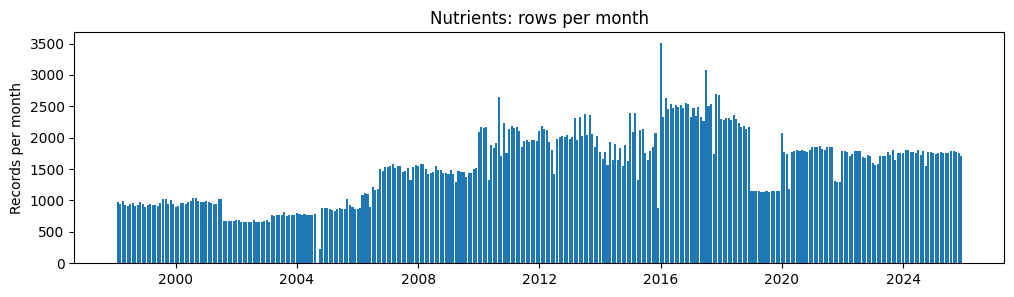

First date: 1998-02-24 00:00:00 | Last date: 2025-12-29 00:00:00


In [15]:
# Time coverage
plot_monthly_counts(nutr['date'], 'Nutrients: rows per month')
print('First date:', nutr['date'].min(), '| Last date:', nutr['date'].max())

In [16]:
# Spatial coverage: there are no coordinates in this file, so we can only count stations
print(nutr.groupby('DataSource')['Actual_StationID'].nunique())

DataSource
SARASOTAES_WQ                40
SARASOTA_COASTALCREEK_WQ    122
Name: Actual_StationID, dtype: int64


In [17]:
# Value checks

# Water temperature is in deg F. Values above 100 F are impossible.
temp = nutr[nutr['Characteristic'].str.startswith('Temperature')]
print('Water temp > 100 F:', (temp['Result_Value'] > 100).sum(), '| max =', temp['Result_Value'].max())
print(temp.loc[temp['Result_Value'] > 100, 'Result_Comment'].value_counts().head(3), '\n')

# Dissolved oxygen above 25 mg/L is not realistic
do = nutr[nutr['Characteristic'] == 'Dissolved oxygen (DO)']
print('DO > 25 mg/L:', (do['Result_Value'] > 25).sum())

# pH must be between 0 and 14
ph = nutr[nutr['Characteristic'] == 'pH']
print('pH outside 0-14:', ((ph['Result_Value'] < 0) | (ph['Result_Value'] > 14)).sum(), '| max =', ph['Result_Value'].max(), '\n')

# Qualifier codes (U = below detection limit, I, J, B, ...)
print(nutr['Value_Qualifier'].value_counts().head(10), '\n')

print('Blank sample times:', nutr['Activity_Start_Time'].isna().sum())

Water temp > 100 F: 4965 | max = 412.8548
Result_Comment
Water Institute Calculated    4934
Name: count, dtype: int64 

DO > 25 mg/L: 57
pH outside 0-14: 3 | max = 758.0 

Value_Qualifier
I      45566
U      22590
       10428
B       8394
J        477
IJ       283
G         41
IJG       28
C         15
UJ        14
Name: count, dtype: int64 

Blank sample times: 82051


In [18]:
# Duplicates
print('Exact duplicates:', nutr.duplicated().sum())

# The same sample often appears twice (once with depth in m, once in ft)
key = ['Actual_StationID', 'date', 'Characteristic', 'RelativeDepth']
groups = nutr.drop_duplicates().groupby(key, dropna=False)['Result_Value'].agg(['min', 'max', 'count'])
groups = groups[groups['count'] > 1]
print('Station/date/parameter/depth groups with more than one value:', len(groups))

# Pairs that differ by ~1000x are unit errors
unit_errors = groups[(groups['min'] > 0) & (groups['max'] > 500 * groups['min'])]
print('Groups that differ by more than 500x:', len(unit_errors))
unit_errors.reset_index()['Characteristic'].value_counts()

Exact duplicates: 7374
Station/date/parameter/depth groups with more than one value: 25966
Groups that differ by more than 500x: 574


,count
Characteristic,
"Nitrogen, ammonia as N",574


### Findings and decisions: Nutrients
- **Long format** → pivot to one row per station × date in notebook 02.
- **Parameter name variants** (temperature, conductance, DO saturation) → map them to one short name each.
- **Temperature in °F with values > 100 °F** (mostly "Water Institute Calculated" rows) → set to NaN, then convert to °C.
- **DO > 25 mg/L** → NaN. **pH up to 758** → set pH outside 0–14 to NaN.
- **Exact duplicates** → drop. **Same sample reported twice** → one value per station × date × parameter × depth class.
- **~1000× unit errors** (mostly ammonia) → flag them and keep the smaller value.
- **Below detection (`U`)** → keep a flag column and use MDL/2 as the value.
- **No station coordinates** → nutrients can only be joined at region level until we get the Water Atlas station list (open item for the advisor).

---
## 3. Cyanotoxins (optional)

**Source:** Water Quality Portal (STORET / WQX), Florida organisations — https://www.waterqualitydata.us/

**One row =** one toxin measured in one water sample (**long format**).

**Scope:** 2,877 sites statewide, mostly **lakes**. The file name says 2026, but the data ends in **Jan 2025**.

**Role:** optional. These are **freshwater cyanobacteria toxins, not *K. brevis***, so they are never used for the main label.

In [19]:
cyano = pd.read_csv(os.path.join(DATA, 'florida_cyanotoxins_2015-01-01_to_2026-06-17.csv'), low_memory=False)

# Dates are stored as epoch milliseconds (in scientific notation). The day part is still correct.
cyano['date'] = pd.to_datetime(cyano['Activity_StartDate'], unit='ms').dt.normalize()

print('Shape:', cyano.shape)
cyano.head()

Shape: (98884, 66)


,Org_Identifier,Org_FormalName,Project_Identifier,Location_Identifier,Location_Name,Location_Type,Location_State,Location_HUCEightDigitCode,Location_HUCTwelveDigitCode,Location_TribalLand,...,Result_LabSamplePrepProfileDown,ProviderName,Result_CharacteristicComparable,Result_CharacteristicGroup,Org_Type,LastChangeDate,USGSpcode,ObjectId,Value_control,date
0,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10246,NCA_FL-10246,Ocean,Florida,NaN,NaN,NaN,...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,23431,A,2015-06-01
1,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10245,NCA_FL-10245,Ocean,Florida,NaN,NaN,NaN,...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,22625,A,2015-06-02
2,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10297,NCA_FL-10297,Ocean,Florida,NaN,NaN,NaN,...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,22713,A,2015-06-02
3,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10299,NCA_FL-10299,Ocean,Florida,NaN,NaN,NaN,...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,25340,A,2015-06-03
4,NARS_WQX,EPA National Aquatic Resources Survey (NARS),"[""NARS_NCCA2015""]",NARS_WQX-NCA_FL-10248,NCA_FL-10248,Ocean,Florida,NaN,NaN,NaN,...,NaN,STORET,NaN,"Cyanotoxins, Phytotoxins",Federal/US Government,Fri Jan 31 08:59:46 GMT 2025,NaN,25355,A,2015-06-03


In [20]:
# 20 columns are completely empty, so leave them out of the profile
empty_cols = cyano.columns[cyano.isna().all()]
print('Empty columns:', len(empty_cols))

profile(cyano.drop(columns=empty_cols))

Empty columns: 20


,dtype,pct_missing,n_unique,min,max
Activity_ActivityIdentifier,object,0.0,7402,NaN,NaN
Activity_DepthHeightMeasure,float64,0.2,113,3.000000e-02,1.100000e+01
Activity_DepthHeightMeasureUnit,object,0.2,2,NaN,NaN
Activity_Media,object,0.0,1,NaN,NaN
Activity_MediaSubdivision,object,0.2,1,NaN,NaN
Activity_StartDate,float64,0.0,1204,1.433130e+12,1.735790e+12
Activity_StartTime,object,0.2,482,NaN,NaN
Activity_StartTimeZone,object,0.2,2,NaN,NaN
Activity_TypeCode,object,0.0,1,NaN,NaN
DataQuality_ResultComment,object,1.8,119,NaN,NaN


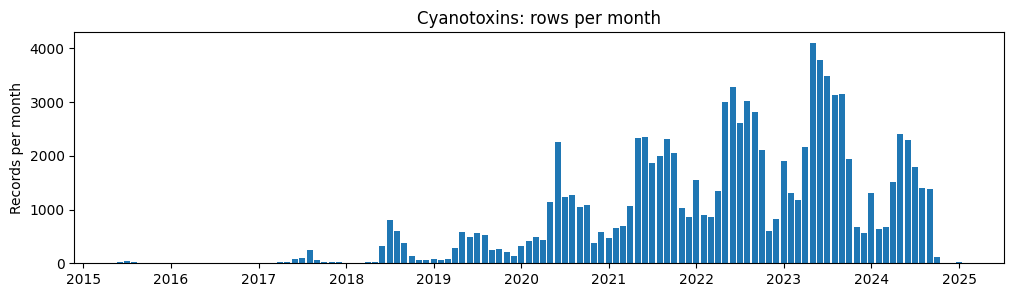

First date: 2015-06-01 00:00:00 | Last date: 2025-01-02 00:00:00


In [21]:
# Time coverage
plot_monthly_counts(cyano['date'], 'Cyanotoxins: rows per month')
print('First date:', cyano['date'].min(), '| Last date:', cyano['date'].max())

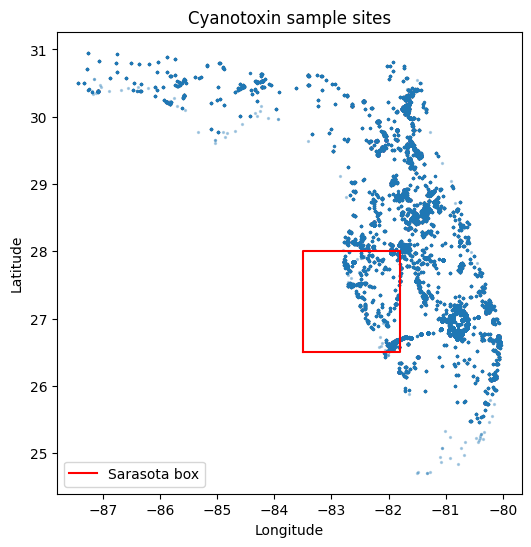

Location_Type
Lake                        65275
River/Stream                12885
Canal Drainage              11086
Canal Transport              4752
Estuary                      3324
Reservoir                    1172
Ocean                         184
Spring                        122
Channelized Stream             57
Other-Surface Water            16
Wetland Undifferentiated       11
Name: count, dtype: int64


In [22]:
# Spatial coverage
plot_points(cyano['Location_Latitude'], cyano['Location_Longitude'], 'Cyanotoxin sample sites')
print(cyano['Location_Type'].value_counts())

In [23]:
# Value checks

# A detection = measured value above the detection limit (non-detects are marked **U** in the comments)
cyano['detected'] = cyano['Reslt_Measre'] > cyano['DetectionLimit_MeasureA']
print('Non-detects (%):', round((1 - cyano['detected'].mean()) * 100, 1))
inside = in_box(cyano['Location_Latitude'], cyano['Location_Longitude'])
print('Detections (all Florida):', cyano['detected'].sum())
print('Detections inside the Sarasota box:', (cyano['detected'] & inside).sum(), '\n')

print(cyano['Result_MeasureUnit'].value_counts())
print(cyano['Result_Characteristic'].value_counts().head(10))

Non-detects (%): 98.4
Detections (all Florida): 1601
Detections inside the Sarasota box: 175 

Result_MeasureUnit
ug/L    98824
Name: count, dtype: int64
Result_Characteristic
Cylindrospermopsin           7147
Microcystin LA               7107
Microcystin RR               7107
Microcystin YR               7107
Microcystin LR               7107
Microcystin LF               7097
Microcystin LY               7097
Anatoxin-A                   7092
Microcystin WR               6368
Microcystin LR, Desmethyl    6368
Name: count, dtype: int64


In [24]:
# Duplicates
print('Exact duplicates:', cyano.duplicated().sum())

key = ['Location_Identifier', 'date', 'Result_Characteristic']
print('Same site, date and toxin:', cyano.duplicated(subset=key).sum())

Exact duplicates: 0
Same site, date and toxin: 305


### Findings and decisions: Cyanotoxins
- **Freshwater toxins, mostly lakes** → optional feature only, never part of the label.
- **Dates in epoch ms (scientific notation)** → convert with `unit='ms'` and keep only the date.
- **98% non-detects**, 2015–17 sparse, only ~175 detections in the Sarasota box → at most a weekly "number of detections in the region" feature.
- **Data ends Jan 2025** despite the file name → ask the advisor if there is a newer extract.
- **20 empty columns** → drop.

---
## 4. Bradenton weather station

**Source:** NOAA NCEI daily cooperative observer (COOP) station 80945, Bradenton, FL.

**One row =** one day: precipitation (inches) and max / min / mean air temperature (°F).

**Scope:** one station, 2015-01-01 → 2025-12-31, daily. Wide format.

**Role:** features (rain and air temperature).

In [25]:
# Header names have leading spaces, so we use skipinitialspace and strip them
brad = pd.read_csv(os.path.join(DATA, 'bradentonFL_tempData.csv'), skipinitialspace=True)
brad.columns = brad.columns.str.strip()
brad['date'] = pd.to_datetime(dict(year=brad['YEAR'], month=brad['MONTH'], day=brad['DAY']))

print('Shape:', brad.shape)
brad.head()

Shape: (4018, 9)


,COOPID,YEAR,MONTH,DAY,PRECIPITATION,MAX TEMP,MIN TEMP,MEAN TEMP,date
0,80945,2015,1,1,0.0,74.0,60.0,NaN,2015-01-01
1,80945,2015,1,2,0.0,78.0,64.0,NaN,2015-01-02
2,80945,2015,1,3,0.0,85.0,70.0,NaN,2015-01-03
3,80945,2015,1,4,0.0,83.0,69.0,NaN,2015-01-04
4,80945,2015,1,5,0.0,75.0,61.0,NaN,2015-01-05


In [26]:
profile(brad)

,dtype,pct_missing,n_unique,min,max
COOPID,int64,0.0,1,80945.00,80945.00
DAY,int64,0.0,31,1.00,31.00
MAX TEMP,float64,0.0,56,-99.90,101.00
MEAN TEMP,float64,18.2,100,-99.90,91.00
MIN TEMP,float64,0.0,52,-99.90,83.00
MONTH,int64,0.0,12,1.00,12.00
PRECIPITATION,float64,0.0,207,-99.99,11.65
YEAR,int64,0.0,11,2015.00,2025.00
date,datetime64[ns],0.0,4018,NaN,NaN


First day: 2015-01-01 00:00:00 | Last day: 2025-12-31 00:00:00
Missing days: 0


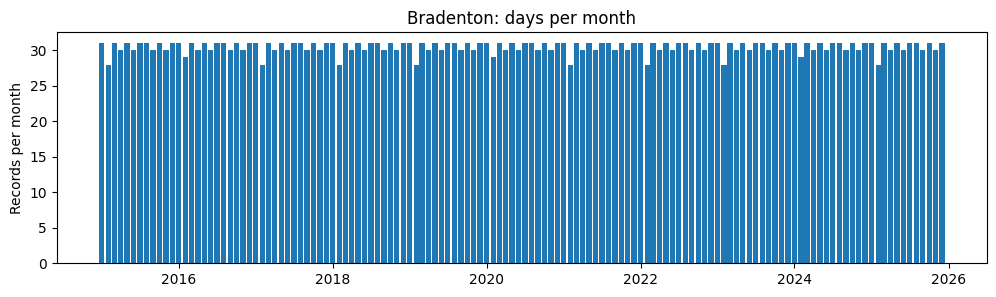

In [27]:
# Time coverage: check for missing days
all_days = pd.date_range(brad['date'].min(), brad['date'].max(), freq='D')
print('First day:', brad['date'].min(), '| Last day:', brad['date'].max())
print('Missing days:', len(all_days) - brad['date'].nunique())

plot_monthly_counts(brad['date'], 'Bradenton: days per month')

**Spatial coverage:** a single station (Bradenton), so there is no map for this dataset.

In [28]:
# Value checks: -99.9 and -99.99 are "missing" codes (sentinels)
for col in ['PRECIPITATION', 'MAX TEMP', 'MIN TEMP', 'MEAN TEMP']:
    n_sentinel = brad[col].isin([-99.9, -99.99]).sum()
    n_blank = brad[col].isna().sum()
    print(f'{col}: {n_sentinel} sentinel values, {n_blank} blanks')

PRECIPITATION: 5 sentinel values, 0 blanks
MAX TEMP: 7 sentinel values, 0 blanks
MIN TEMP: 8 sentinel values, 0 blanks
MEAN TEMP: 5 sentinel values, 731 blanks


In [29]:
# Duplicates
print('Exact duplicates:', brad.duplicated().sum())
print('Duplicate dates:', brad['date'].duplicated().sum())

Exact duplicates: 0
Duplicate dates: 0


### Findings and decisions: Bradenton
- **Sentinels `-99.9` / `-99.99`** → read them as NaN.
- **`MEAN TEMP` blank ~18%** → recompute as (max + min) / 2.
- **Units °F and inches** → convert to °C and mm.
- **Leading spaces in column names** → strip them.
- No missing days and no duplicates.

---
## 5. KSRQ airport station (Sarasota wind & temperature)

**Source:** ERDDAP export of the Sarasota–Bradenton airport (KSRQ) weather station. (The same data is also in a `.json` file, we only use the CSV.)

**One row =** one weather report: pressure, dew point, air temperature, visibility, wind speed, gust and direction, each with a QC flag.

**Scope:** one point, 2022-07-11 → 2026-06-18, hourly plus extra special reports. Wide format.

**Role:** features (pressure, air temperature, dew point; wind as a cross-check).

In [30]:
# Row 2 of the file is a units row, so skip it
ksrq = pd.read_csv(os.path.join(DATA, 'Sarasota_Wind&Temp.csv'), skiprows=[1])
ksrq['time'] = pd.to_datetime(ksrq['time']).dt.tz_localize(None)   # UTC; time zone dropped for plotting

print('Shape:', ksrq.shape)
ksrq.head()

Shape: (41285, 16)


,time,z,air_pressure_at_mean_sea_level,air_pressure_at_mean_sea_level_qc_agg,dew_point_temperature,dew_point_temperature_qc_agg,air_temperature,air_temperature_qc_agg,visibility_in_air,visibility_in_air_qc_agg,wind_speed_of_gust,wind_speed_of_gust_qc_agg,wind_speed,wind_speed_qc_agg,wind_from_direction,wind_from_direction_qc_agg
0,2022-07-11 21:53:00,0.0,1012.5,2,23.9,2,30.0,2,16093.44,2,NaN,2,5.144444,2,230.0,2
1,2022-07-11 22:53:00,0.0,1012.8,2,22.8,2,30.0,2,16093.44,2,9.26,2,5.658889,2,220.0,2
2,2022-07-11 23:53:00,0.0,1013.1,2,23.9,2,29.4,2,16093.44,2,NaN,2,5.144444,2,230.0,2
3,2022-07-12 00:53:00,0.0,1013.4,2,23.3,2,28.9,2,16093.44,2,NaN,2,4.630000,2,240.0,2
4,2022-07-12 01:53:00,0.0,1014.3,2,23.9,2,28.9,2,16093.44,2,NaN,2,4.115556,2,260.0,2


In [31]:
profile(ksrq)

,dtype,pct_missing,n_unique,min,max
air_pressure_at_mean_sea_level,float64,18.4,346,961.500000,1031.700000
air_pressure_at_mean_sea_level_qc_agg,int64,0.0,1,2.000000,2.000000
air_temperature,float64,0.3,103,-60.600000,50.000000
air_temperature_qc_agg,int64,0.0,1,2.000000,2.000000
dew_point_temperature,float64,0.4,92,-15.600000,27.800000
dew_point_temperature_qc_agg,int64,0.0,1,2.000000,2.000000
time,datetime64[ns],0.0,41285,NaN,NaN
visibility_in_air,float64,0.6,24,209.214720,281635.200000
visibility_in_air_qc_agg,int64,0.0,1,2.000000,2.000000
wind_from_direction,float64,2.3,40,0.000000,360.000000


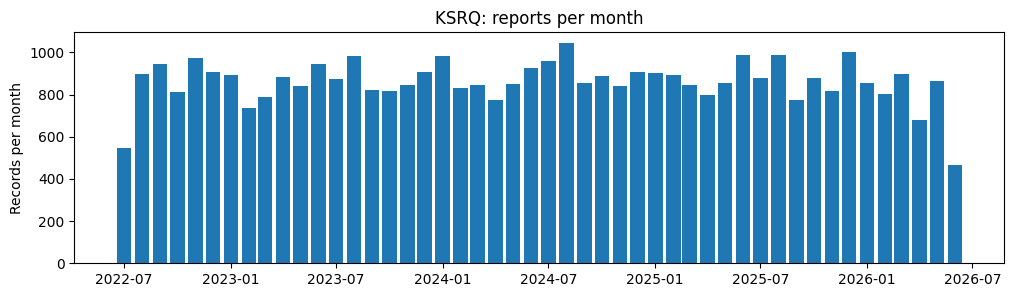

Special reports (not at :53): 7848


In [32]:
# Time coverage
plot_monthly_counts(ksrq['time'], 'KSRQ: reports per month')

# Regular reports are at minute :53, the rest are special (sub-hourly) reports
print('Special reports (not at :53):', (ksrq['time'].dt.minute != 53).sum())

**Spatial coverage:** a single point (the airport), so there is no map for this dataset.

In [33]:
# Value checks
bad_temp = (ksrq['air_temperature'] < -10) | (ksrq['air_temperature'] > 45)
print('Air temp < -10 C or > 45 C:', bad_temp.sum(), '| min =', ksrq['air_temperature'].min(), '| max =', ksrq['air_temperature'].max())
print('Max visibility (km):', ksrq['visibility_in_air'].max() / 1000)
print('Gust missing (%):', round(ksrq['wind_speed_of_gust'].isna().mean() * 100, 1))
print('Pressure missing (%):', round(ksrq['air_pressure_at_mean_sea_level'].isna().mean() * 100, 1))

# QC flags: 2 means "not evaluated"
qc_cols = [col for col in ksrq.columns if col.endswith('_qc_agg')]
print('QC flag values:', pd.unique(ksrq[qc_cols].values.ravel()))

Air temp < -10 C or > 45 C: 7 | min = -60.6 | max = 50.0
Max visibility (km): 281.6352
Gust missing (%): 87.0
Pressure missing (%): 18.4
QC flag values: [2]


In [34]:
# Duplicates
print('Exact duplicates:', ksrq.duplicated().sum())
print('Duplicate time stamps:', ksrq['time'].duplicated().sum())

Exact duplicates: 0
Duplicate time stamps: 0


### Findings and decisions: KSRQ
- **Units row** → skip row 2 when reading.
- **Special sub-hourly reports** → resample to daily, then weekly.
- **Air-temp outliers (−60.6 / 50 °C)** → set values outside −10 to 45 °C to NaN.
- **Gust missing 87%** → normal (gust is only reported when gusty); don't use it.
- **Pressure missing 18%** → daily mean ignores the NaN.
- **QC flag = 2 everywhere (not evaluated)** → the flags don't help, rely on our own range checks.
- **Wind direction** → never average degrees; convert to u/v components first.
- Starts in **July 2022** → optional feature with a `has_ksrq` flag.

---
## 6. Mote Marine water temperature

**Source:** ERDDAP export of the Mote Marine Laboratory sensor (27.329, −82.556), 2 m depth. (Same data in a `.json` file, we only use the CSV.)

**One row =** one hourly water temperature reading (°C) with a QC flag.

**Scope:** one point, 2020-08-13 → 2025-03-26, hourly.

**Role:** feature (water temperature).

In [35]:
# Row 2 is a units row
mote = pd.read_csv(os.path.join(DATA, 'MoteMarine_BottomTemp.csv'), skiprows=[1])
mote['time'] = pd.to_datetime(mote['time']).dt.tz_localize(None)   # UTC

print('Shape:', mote.shape)
mote.head()

Shape: (31729, 6)


,time,latitude,longitude,z,sea_water_temperature,sea_water_temperature_qc_agg
0,2020-08-13 15:00:00,27.3292,-82.5564,-2.0,30.929,1
1,2020-08-13 16:00:00,27.3292,-82.5564,-2.0,31.073,1
2,2020-08-13 17:00:00,27.3292,-82.5564,-2.0,31.217,1
3,2020-08-13 18:00:00,27.3292,-82.5564,-2.0,31.274,1
4,2020-08-13 19:00:00,27.3292,-82.5564,-2.0,31.390,1


In [36]:
profile(mote)

,dtype,pct_missing,n_unique,min,max
latitude,float64,0.0,1,27.3292,27.3292
longitude,float64,0.0,1,-82.5564,-82.5564
sea_water_temperature,float64,0.0,876,11.4210,33.0460
sea_water_temperature_qc_agg,int64,0.0,3,1.0000,4.0000
time,datetime64[ns],0.0,31729,NaN,NaN
z,float64,0.0,1,-2.0000,-2.0000


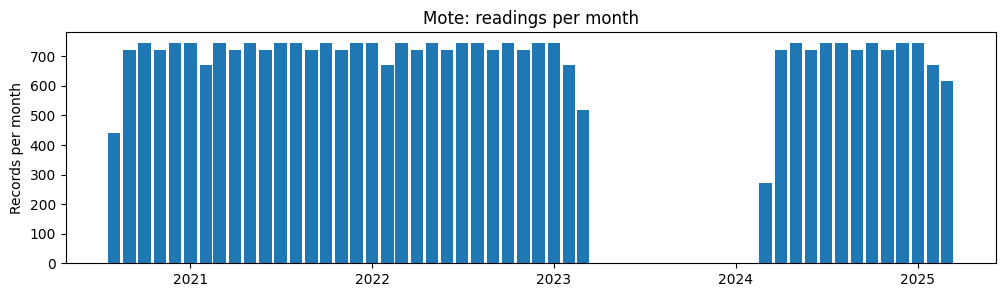

Gap from 2023-03-22 15:00:00 to 2024-03-20 16:00:00 = 364 days 01:00:00
Gap from 2020-08-13 15:00:00 to 2020-08-13 16:00:00 = 0 days 01:00:00
Gap from 2020-08-13 16:00:00 to 2020-08-13 17:00:00 = 0 days 01:00:00


In [37]:
# Time coverage
plot_monthly_counts(mote['time'], 'Mote: readings per month')

# The three biggest gaps between readings
gaps = mote['time'].diff()
for i in gaps.nlargest(3).index:
    print('Gap from', mote.loc[i - 1, 'time'], 'to', mote.loc[i, 'time'], '=', gaps[i])

**Spatial coverage:** a single sensor, so there is no map for this dataset.

In [38]:
# Value checks: QC flag 1 = good, 3 = suspect, 4 = fail
print(mote['sea_water_temperature_qc_agg'].value_counts())
print('Temperature min / max:', mote['sea_water_temperature'].min(), mote['sea_water_temperature'].max())

sea_water_temperature_qc_agg
1    31629
3       98
4        2
Name: count, dtype: int64
Temperature min / max: 11.421 33.046


In [39]:
# Duplicates
print('Exact duplicates:', mote.duplicated().sum())
print('Duplicate time stamps:', mote['time'].duplicated().sum())

Exact duplicates: 0
Duplicate time stamps: 0


### Findings and decisions: Mote
- **Units row** → skip row 2.
- **~100 rows with QC flag 3/4** → drop them.
- **364-day gap (Mar 2023 → Mar 2024)** → leave it as NaN, add a `has_mote` flag.
- Hourly → resample to daily, then weekly mean / max.

---
## 7. Satellite chlorophyll (7A, gap-filled)

**Source:** NOAA CoastWatch ERDDAP, dataset `noaacwNPPN20S3ASCIDINEOF2kmDaily` — https://coastwatch.noaa.gov/erddap/griddap/noaacwNPPN20S3ASCIDINEOF2kmDaily.html (VIIRS + OLCI, gap-filled with DINEOF).

**One value =** chlorophyll-a (mg/m³) for one 2 km pixel on one day. NetCDF grid (time × latitude × longitude).

**Scope:** the Sarasota box, 2018-01-01 → 2026-09-10, daily.

**Role:** feature (recommended satellite chlorophyll source, see the comparison at the end).

In [40]:
ds = xr.open_dataset(os.path.join(DATA, 'Chlorophyll_subset_sarasota_2018_2026.nc'))
print(ds.attrs['title'])
print(ds.attrs['subset_note'])
ds

Chlorophyll (Gap-filled DINEOF), NOAA S-NPP NOAA-20 VIIRS and Copernicus S-3A OLCI, Science Quality, Global 2km, 2018-recent, Daily
Subset of ERDDAP dataset noaacwNPPN20S3ASCIDINEOF2kmDaily (https://coastwatch.noaa.gov/erddap/griddap/noaacwNPPN20S3ASCIDINEOF2kmDaily.html), lat 26.5-28, lon -83.5 to -81.8, downloaded 2026-09-22 in 5-day chunks and merged.


<xarray.Dataset> Size: 76MB
Dimensions:    (time: 3160, latitude: 73, longitude: 82)
Coordinates:
  * time       (time) datetime64[ns] 25kB 2018-01-01T12:00:00 ... 2026-09-10T...
  * latitude   (latitude) float32 292B 28.01 27.99 27.97 ... 26.55 26.53 26.51
  * longitude  (longitude) float32 328B -83.49 -83.47 -83.45 ... -81.82 -81.8
Data variables:
    chlor_a    (time, latitude, longitude) float32 76MB ...
Attributes: (12/62)
    acknowledgement:                           To cite these data in a paper,...
    cdm_data_type:                             Grid
    Conventions:                               CF-1.10, COARDS, ACDD-1.3
    creator_email:                             coastwatch.info@noaa.gov
    creator_name:                              NOAA CoastWatch
    creator_type:                              institution
    ...                                        ...
    testOutOfDate:                             now-23days
    time_coverage_end:                         2026-09-10T12:00:00Z
    time_coverage_start:                       2018-01-01T12:00:00Z
    title:                                     Chlorophyll (Gap-filled DINEOF...
    Westernmost_Easting:                       -83.489586
    subset_note:                               Subset of ERDDAP dataset noaac...

In [41]:
# Load the chlorophyll grid into memory (about 76 MB)
chl = ds['chlor_a'].load()
chl_dates = pd.Series(pd.to_datetime(chl['time'].values)).dt.normalize()

# Missing days and empty days
chl_all_days = pd.date_range(chl_dates.min(), chl_dates.max(), freq='D')
valid_per_day = chl.notnull().sum(['latitude', 'longitude']).values
print('Grid shape (time, lat, lon):', chl.shape)
print('Missing days:', len(chl_all_days) - chl_dates.nunique())
print('Days with no valid pixels:', (valid_per_day == 0).sum())

Grid shape (time, lat, lon): (3160, 73, 82)
Missing days: 15
Days with no valid pixels: 5


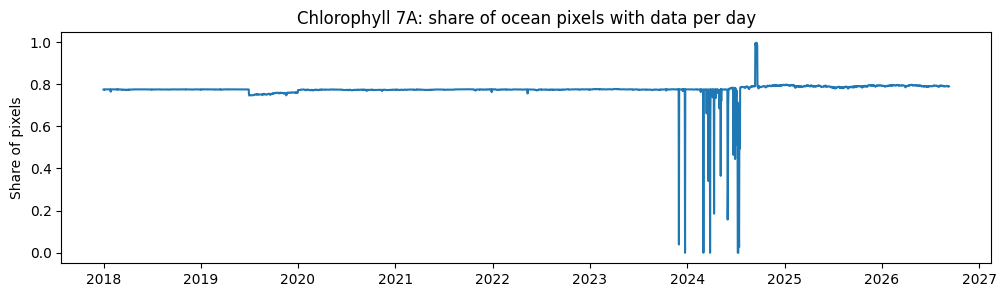

In [42]:
# Time coverage: share of ocean pixels with a value on each day
ocean = chl.notnull().any('time')     # pixels that have data at least once (land never has data)
share = valid_per_day / int(ocean.sum())

plt.figure(figsize=(12, 3))
plt.plot(chl_dates, share)
plt.title('Chlorophyll 7A: share of ocean pixels with data per day')
plt.ylabel('Share of pixels')
plt.show()

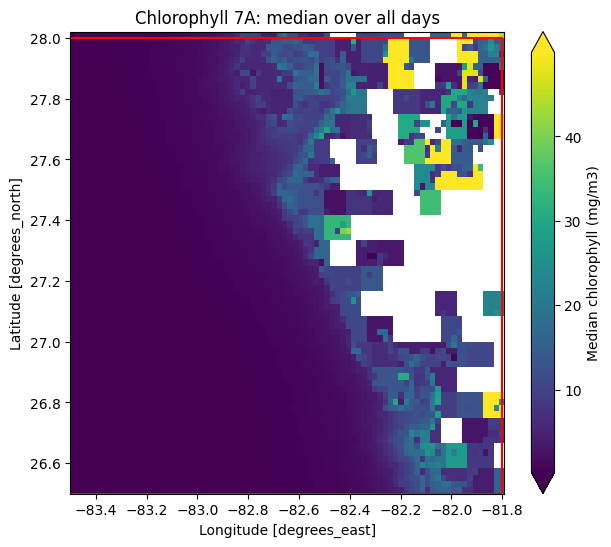

In [43]:
# Spatial coverage: median chlorophyll of every pixel, with the study box
fig, ax = plt.subplots(figsize=(7, 6))
chl.median('time').plot(ax=ax, robust=True, cbar_kwargs={'label': 'Median chlorophyll (mg/m3)'})
draw_box(ax)
ax.set_title('Chlorophyll 7A: median over all days')
plt.show()

In [44]:
# Value checks
print('Units:', chl.attrs['units'])
print('Min / max:', float(chl.min()), float(chl.max()))
print('Pixel-days >= 50 mg/m3 (turbid nearshore water):', int((chl >= 50).sum()))

Units: mg m^-3
Min / max: 0.0018590247491374612 99.99664306640625
Pixel-days >= 50 mg/m3 (turbid nearshore water): 70644


In [45]:
# Duplicates
print('Duplicate days:', chl_dates.duplicated().sum())

Duplicate days: 0


### Findings and decisions: Chlorophyll 7A
- **15 missing days, 5 days with no valid pixels** → leave as NaN.
- **Cloudy pixels are DINEOF reconstructions**, not observations → fine for features, mention it in the README.
- **~70k pixel-days ≥ 50 mg/m³** (turbid nearshore water) → clip at 50 before averaging.
- Times are 12:00 UTC (08:00 local), so the date part is already the local date.

---
## 8. Gridded ocean wind (u component only)

**Source:** ERDDAP export (dataset ID still to be recorded, open item). 0.25° grid, 7 × 7 cells, 6-hourly. (Same data in a `.json` file, we only use the CSV.)

**One row =** the east–west wind component `uwnd` (m/s) at one grid cell and time.

**Scope:** 2019-01-01 → 2026-09-15.

**Role:** feature, but **incomplete**: `vwnd` (north–south) is missing.

In [46]:
# Row 2 is a units row. Longitude runs 0-360, so subtract 360.
wind = pd.read_csv(os.path.join(DATA, 'SarasotaWindData.csv'), skiprows=[1])
wind['time'] = pd.to_datetime(wind['time']).dt.tz_localize(None)   # UTC
wind['longitude'] = wind['longitude'] - 360

print('Shape:', wind.shape)
print('Columns:', wind.columns.tolist())
wind.head()

Shape: (549780, 4)
Columns: ['time', 'latitude', 'longitude', 'uwnd']


,time,latitude,longitude,uwnd
0,2019-01-01,26.625,-83.375,-4.081281
1,2019-01-01,26.625,-83.125,-3.825571
2,2019-01-01,26.625,-82.875,-3.380656
3,2019-01-01,26.625,-82.625,-2.561112
4,2019-01-01,26.625,-82.375,-1.520360


In [47]:
profile(wind)

,dtype,pct_missing,n_unique,min,max
latitude,float64,0.0,7,26.625000,28.12500
longitude,float64,0.0,7,-83.375000,-81.87500
time,datetime64[ns],0.0,11220,NaN,NaN
uwnd,float64,0.0,547646,-23.263628,35.97459


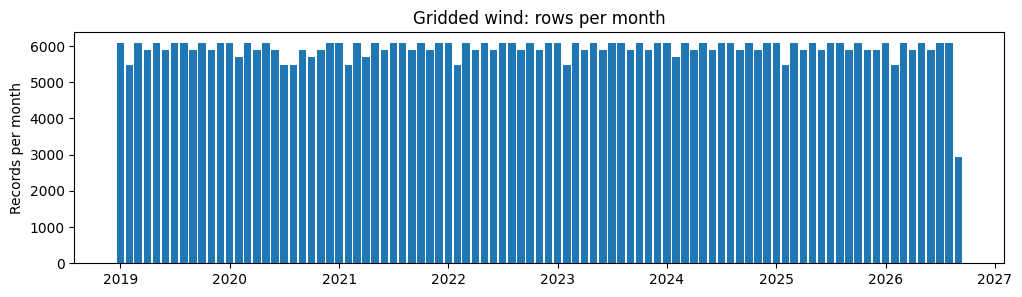

Time step: time
0 days 06:00:00    11210
1 days 06:00:00        8
2 days 06:00:00        1
Name: count, dtype: int64


In [48]:
# Time coverage
plot_monthly_counts(wind['time'], 'Gridded wind: rows per month')
print('Time step:', wind['time'].drop_duplicates().diff().value_counts().head(3))

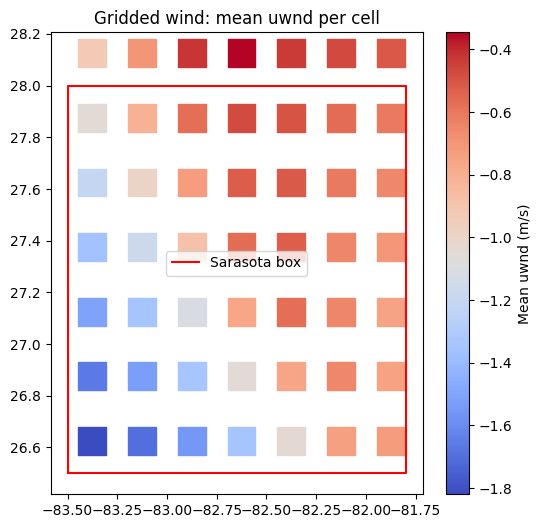

In [49]:
# Spatial coverage: mean uwnd of every grid cell
cell_mean = wind.groupby(['latitude', 'longitude'])['uwnd'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 6))
points = ax.scatter(cell_mean['longitude'], cell_mean['latitude'], c=cell_mean['uwnd'],
                    s=400, marker='s', cmap='coolwarm')
plt.colorbar(points, label='Mean uwnd (m/s)')
draw_box(ax)
ax.set_title('Gridded wind: mean uwnd per cell')
ax.legend()
plt.show()

In [50]:
# Value checks
print('uwnd min / max:', wind['uwnd'].min(), wind['uwnd'].max())
print('Time of the strongest wind:', wind.loc[wind['uwnd'].abs().idxmax(), 'time'])   # Hurricane Milton, Oct 2024

uwnd min / max: -23.263628 35.97459
Time of the strongest wind: 2024-10-10 00:00:00


In [51]:
# Duplicates
print('Exact duplicates:', wind.duplicated().sum())
print('Same time and cell:', wind.duplicated(subset=['time', 'latitude', 'longitude']).sum())

Exact duplicates: 0
Same time and cell: 0


### Findings and decisions: Gridded wind
- **A few missing 6-hour steps** (gaps of 1–2 days) → the daily mean just uses what is there.
- **Only `uwnd`, no `vwnd`** → we can't compute speed, direction or alongshore wind yet. Ask the teammate who collected it to add `vwnd`.
- **Longitude 0–360** → subtract 360.
- **Units row** → skip row 2.
- Values look right (the extremes fall on 2024-10-10, Hurricane Milton).
- Use the **offshore** cells only, aggregate to daily, then weekly.

---
## Summary table of all datasets

Rows, columns and dates are computed from the files loaded above. Datasets 7B and 7C are not in our Drive folder, so their numbers are typed in from the data-prep audit.

In [52]:
def date_text(dates):
    """First and last date as text."""
    return f"{dates.min():%Y-%m-%d} to {dates.max():%Y-%m-%d}"


summary = pd.DataFrame([
    {'dataset': 'HABSOS cell counts', 'file': 'habsos_cellcounts.csv',
     'rows': len(habsos), 'cols': habsos.shape[1], 'dates': date_text(habsos['SAMPLE_DATE']),
     'grain': 'Irregular samples, Gulf coast', 'role': 'Target',
     'main_issues': '2022-23 nearly empty; outliers; duplicates; 856 missing CATEGORY; wind columns empty'},

    {'dataset': 'Nutrients (Water Atlas)', 'file': 'NutrientsFL_2006_2025.csv',
     'rows': len(nutr), 'cols': nutr.shape[1] - 1, 'dates': date_text(nutr['date']),
     'grain': 'Long format, 162 stations, no lat/lon', 'role': 'Features',
     'main_issues': 'Name variants; temp in F with values > 100; pH up to 758; m/ft duplicate rows; ammonia x1000 errors; U qualifiers'},

    {'dataset': 'Cyanotoxins', 'file': 'florida_cyanotoxins_2015-01-01_to_2026-06-17.csv',
     'rows': len(cyano), 'cols': cyano.shape[1] - 2, 'dates': date_text(cyano['date']),
     'grain': 'Long format, 2,877 sites, mostly lakes', 'role': 'Optional',
     'main_issues': 'Epoch-ms dates; 98% non-detects; ends Jan 2025; 20 empty columns'},

    {'dataset': 'Bradenton weather', 'file': 'bradentonFL_tempData.csv',
     'rows': len(brad), 'cols': brad.shape[1] - 1, 'dates': date_text(brad['date']),
     'grain': 'Daily, 1 station', 'role': 'Features',
     'main_issues': '-99.9 sentinels; F and inches; MEAN TEMP 18% blank'},

    {'dataset': 'KSRQ airport station', 'file': 'Sarasota_Wind&Temp.csv',
     'rows': len(ksrq), 'cols': ksrq.shape[1], 'dates': date_text(ksrq['time']),
     'grain': 'Hourly + special reports, 1 point', 'role': 'Features',
     'main_issues': 'Units row; sub-hourly reports; air-temp outliers; gust 87% missing; QC not evaluated'},

    {'dataset': 'Mote water temperature', 'file': 'MoteMarine_BottomTemp.csv',
     'rows': len(mote), 'cols': mote.shape[1], 'dates': date_text(mote['time']),
     'grain': 'Hourly, 1 point', 'role': 'Feature',
     'main_issues': 'Units row; 364-day gap Mar 2023 - Mar 2024; ~100 QC 3/4 rows'},

    {'dataset': '7A Chlorophyll (gap-filled)', 'file': 'Chlorophyll_subset_sarasota_2018_2026.nc',
     'rows': chl.shape[0], 'cols': f'{chl.shape[1]} x {chl.shape[2]} grid', 'dates': date_text(chl_dates),
     'grain': 'Daily, 2 km grid', 'role': 'Feature (recommended)',
     'main_issues': '15 missing days; cloudy pixels are reconstructions; very high nearshore values'},

    {'dataset': '7B Chlorophyll (not gap-filled)', 'file': 'ChlorophyllaConcentrationSarasota.csv',
     'rows': 4202008, 'cols': 5, 'dates': '2020-06-15 to 2026-09-05',
     'grain': 'Daily, ~4 km grid', 'role': 'Dropped (superseded by 7A)',
     'main_issues': '75% NaN (clouds); 0-360 longitude; units row; source not recorded'},

    {'dataset': '7C Chlorophyll MODIS (not gap-filled)', 'file': 'ChlorophyllaConcentrationSarasota_Dataset2.csv',
     'rows': 7010094, 'cols': 4, 'dates': '2010-01-01 to 2022-05-31',
     'grain': 'Daily, 4 km grid', 'role': 'Optional (2010-17 history only)',
     'main_issues': '81% NaN; no coverage inside Sarasota Bay; 0-360 longitude; units row'},

    {'dataset': 'Gridded wind (u only)', 'file': 'SarasotaWindData.csv',
     'rows': len(wind), 'cols': wind.shape[1], 'dates': date_text(wind['time']),
     'grain': '6-hourly, 0.25 deg 7 x 7 grid', 'role': 'Feature (incomplete)',
     'main_issues': 'No vwnd; 0-360 longitude; units row'},
])

summary.to_csv(os.path.join(DOCS, 'data_summary.csv'), index=False)
summary

,dataset,file,rows,cols,dates,grain,role,main_issues
0,HABSOS cell counts,habsos_cellcounts.csv,219152,26,1953-08-19 to 2026-05-18,"Irregular samples, Gulf coast",Target,2022-23 nearly empty; outliers; duplicates; 85...
1,Nutrients (Water Atlas),NutrientsFL_2006_2025.csv,514087,18,1998-02-24 to 2025-12-29,"Long format, 162 stations, no lat/lon",Features,Name variants; temp in F with values > 100; pH...
2,Cyanotoxins,florida_cyanotoxins_2015-01-01_to_2026-06-17.csv,98884,65,2015-06-01 to 2025-01-02,"Long format, 2,877 sites, mostly lakes",Optional,Epoch-ms dates; 98% non-detects; ends Jan 2025...
3,Bradenton weather,bradentonFL_tempData.csv,4018,8,2015-01-01 to 2025-12-31,"Daily, 1 station",Features,-99.9 sentinels; F and inches; MEAN TEMP 18% b...
4,KSRQ airport station,Sarasota_Wind&Temp.csv,41285,16,2022-07-11 to 2026-06-18,"Hourly + special reports, 1 point",Features,Units row; sub-hourly reports; air-temp outlie...
5,Mote water temperature,MoteMarine_BottomTemp.csv,31729,6,2020-08-13 to 2025-03-26,"Hourly, 1 point",Feature,Units row; 364-day gap Mar 2023 - Mar 2024; ~1...
6,7A Chlorophyll (gap-filled),Chlorophyll_subset_sarasota_2018_2026.nc,3160,73 x 82 grid,2018-01-01 to 2026-09-10,"Daily, 2 km grid",Feature (recommended),15 missing days; cloudy pixels are reconstruct...
7,7B Chlorophyll (not gap-filled),ChlorophyllaConcentrationSarasota.csv,4202008,5,2020-06-15 to 2026-09-05,"Daily, ~4 km grid",Dropped (superseded by 7A),75% NaN (clouds); 0-360 longitude; units row; ...
8,7C Chlorophyll MODIS (not gap-filled),ChlorophyllaConcentrationSarasota_Dataset2.csv,7010094,4,2010-01-01 to 2022-05-31,"Daily, 4 km grid",Optional (2010-17 history only),81% NaN; no coverage inside Sarasota Bay; 0-36...
9,Gridded wind (u only),SarasotaWindData.csv,549780,4,2019-01-01 to 2026-09-15,"6-hourly, 0.25 deg 7 x 7 grid",Feature (incomplete),No vwnd; 0-360 longitude; units row


## Coverage timeline

One row per dataset. A mark means the dataset has at least one record in that month.

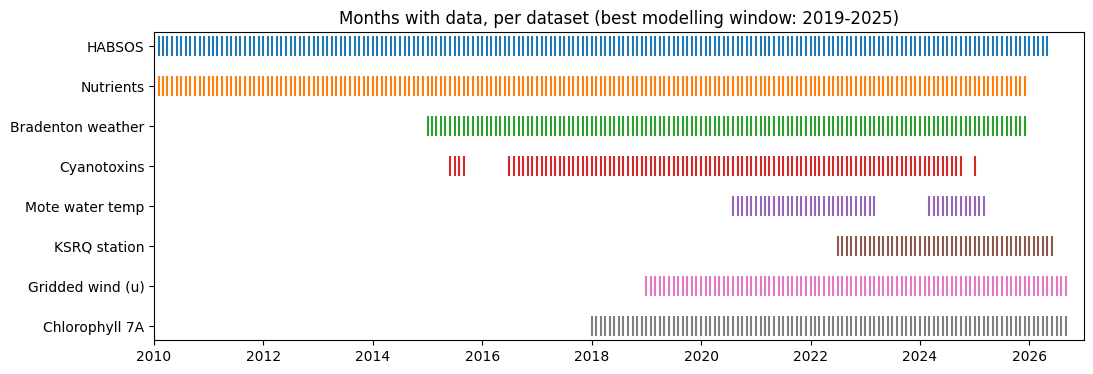

In [53]:
coverage = {
    'HABSOS': habsos['SAMPLE_DATE'],
    'Nutrients': nutr['date'],
    'Bradenton weather': brad['date'],
    'Cyanotoxins': cyano['date'],
    'Mote water temp': mote['time'],
    'KSRQ station': ksrq['time'],
    'Gridded wind (u)': wind['time'],
    'Chlorophyll 7A': chl_dates,
}

fig, ax = plt.subplots(figsize=(12, 4))

for i, (name, dates) in enumerate(coverage.items()):
    months = dates.dt.to_period('M').drop_duplicates().dt.to_timestamp()
    ax.scatter(months, [i] * len(months), marker='|', s=200)

ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage.keys())
ax.set_xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2026-12-31'))
ax.invert_yaxis()
ax.set_title('Months with data, per dataset (best modelling window: 2019-2025)')
plt.show()

## Which satellite chlorophyll dataset to keep

We have three candidates: **7A** (gap-filled, 2 km, the `.nc` file) and two teammate CSVs, **7B** (~4 km) and **7C** (MODIS, 4 km). Only 7A is in our Drive folder, so below we recompute the 7A numbers and take the 7B / 7C numbers from the data-prep audit (same tests, same days and pixels).

The most important test: **how many HABSOS samples have a chlorophyll value on the same day at the nearest pixel?** The model trains on HABSOS rows, so this is what matters.

In [54]:
# Coverage of the box: share of ocean pixels with data per day (computed above as `share`)
median_share = np.median(share)
days_half_covered = (share >= 0.5).mean()

# HABSOS samples in Florida, inside the box, during the 7A period
hab = habsos[(habsos['STATE_ID'] == 'FL')
             & in_box(habsos['LATITUDE'], habsos['LONGITUDE'])
             & (habsos['SAMPLE_DATE'] >= '2018-01-01')]

# 7A time stamps are 12:00 UTC, so keep only the date. Missing days are added as empty maps.
chl_by_day = chl.assign_coords(time=chl_dates.values).reindex(time=chl_all_days)

# Chlorophyll at the nearest pixel, on the same day, for every HABSOS sample
values = chl_by_day.sel(time=xr.DataArray(hab['SAMPLE_DATE'].dt.normalize().values),
                        latitude=xr.DataArray(hab['LATITUDE'].values),
                        longitude=xr.DataArray(hab['LONGITUDE'].values),
                        method='nearest')
has_value = values.notnull().values
is_bloom = (hab['CELLCOUNT'] >= 100000).values

print('HABSOS samples checked:', len(hab))
print('With a same-day 7A value:', has_value.sum())

HABSOS samples checked: 29107
With a same-day 7A value: 27906


In [55]:
comparison = pd.DataFrame({
    'test': ['Median share of ocean pixels with data per day',
             'Days with >= 50% of the box covered',
             'HABSOS samples with a same-day chlorophyll value',
             'Bloom samples (>= 100k cells/L) with a value',
             'Date range'],
    '7A gap-filled 2 km (computed here)': [f'{median_share:.0%}',
                                           f'{days_half_covered:.0%}',
                                           f'{has_value.mean():.0%}',
                                           f'{has_value[is_bloom].mean():.0%}',
                                           date_text(chl_dates)],
    '7B 4 km (audit)': ['27%', '35%', '36%', '48%', '2020-06 to 2026-09'],
    '7C MODIS 4 km (audit)': ['15%', '31%', '10%', '10%', '2010-01 to 2022-05'],
})
comparison

,test,7A gap-filled 2 km (computed here),7B 4 km (audit),7C MODIS 4 km (audit)
0,Median share of ocean pixels with data per day,77%,27%,15%
1,Days with >= 50% of the box covered,99%,35%,31%
2,HABSOS samples with a same-day chlorophyll value,96%,36%,10%
3,Bloom samples (>= 100k cells/L) with a value,98%,48%,10%
4,Date range,2018-01-01 to 2026-09-10,2020-06 to 2026-09,2010-01 to 2022-05


**Decision: keep 7A.**
1. 7A has a chlorophyll value for almost every HABSOS sample (including bloom samples). With 7B or 7C most training rows would have no satellite feature.
2. 7A covers Sarasota Bay and the beaches where HABSOS samples are taken; 7C has no pixels inside the bay.
3. Where 7B / 7C have a real observation, 7A matches it (r ≈ 0.95–0.96, ratio ≈ 1.0), so gap-filling does not change the real measurements.
4. Daily box averages from 7B / 7C change with cloud cover, not with the water.
5. One 42 MB file instead of ~1.2 GB of CSV / JSON.

**Caveats:** cloudy-day values in 7A are DINEOF reconstructions, and 7A has no data before 2018. **Drop 7B.** Keep 7C only if the team wants 2010–2017 history.

## Data-issues log

One row per issue: what it is, which dataset, how serious, what we decided, and who handles it.

In [56]:
issues = pd.DataFrame([
    ('2022-2023 nearly empty', 'HABSOS', 'High', 'Flag weeks as low coverage; never treat no sample as no bloom; ask advisor', 'Data prep + Advisor'),
    ('Samples outside FL / study box and deep samples', 'HABSOS', 'Medium', 'Keep FL, Sarasota box, depth <= 2 m or missing', 'Data prep'),
    ('856 missing CATEGORY', 'HABSOS', 'Low', 'Recompute category from CELLCOUNT', 'Data prep'),
    ('Water temp up to 1503 C, salinity up to 308 ppt', 'HABSOS', 'Low', 'Water temp > 40 C and salinity > 45 ppt set to NaN', 'Data prep'),
    ('Exact and conflicting duplicates', 'HABSOS', 'Medium', 'Drop exact; keep max CELLCOUNT for conflicts', 'Data prep'),
    ('Wind columns ~100% empty', 'HABSOS', 'Low', 'Drop columns', 'Data prep'),
    ('Parameter name variants', 'Nutrients', 'Medium', 'Map to one short name per parameter', 'Data prep'),
    ('Temperature > 100 F', 'Nutrients', 'Medium', 'Set to NaN, then convert F to C', 'Data prep'),
    ('Same sample twice (m and ft rows)', 'Nutrients', 'Medium', 'One value per station x date x parameter x depth class', 'Data prep'),
    ('Ammonia x1000 unit errors', 'Nutrients', 'High', 'Flag pairs > 500x apart; keep the smaller value', 'Data prep'),
    ('pH up to 758', 'Nutrients', 'Low', 'pH outside 0-14 set to NaN', 'Data prep'),
    ('Below-detection values (U)', 'Nutrients', 'Low', 'Flag column; value = MDL / 2', 'Data prep'),
    ('No station coordinates', 'Nutrients', 'High', 'Join at region level; request station list', 'Advisor'),
    ('Freshwater toxins, not K. brevis', 'Cyanotoxins', 'Medium', 'Optional feature only, never in the label', 'Data prep'),
    ('File ends Jan 2025 (name says 2026)', 'Cyanotoxins', 'Low', 'Ask for a newer extract', 'Advisor'),
    ('-99.9 / -99.99 sentinels', 'Bradenton', 'Low', 'Read as NaN', 'Data prep'),
    ('MEAN TEMP 18% blank', 'Bradenton', 'Low', 'Recompute as (max + min) / 2', 'Data prep'),
    ('Air-temp outliers (-60.6 / 50 C)', 'KSRQ', 'Low', 'Values outside -10 to 45 C set to NaN', 'Data prep'),
    ('Sub-hourly special reports', 'KSRQ', 'Low', 'Resample to daily, then weekly', 'Data prep'),
    ('364-day gap Mar 2023 - Mar 2024', 'Mote', 'Medium', 'Leave NaN; add has_mote flag', 'Data prep'),
    ('QC flag 3 / 4 rows', 'Mote', 'Low', 'Drop them', 'Data prep'),
    ('Cloudy pixels are reconstructions', 'Chlorophyll 7A', 'Low', 'Use as features; mention in README', 'Data prep'),
    ('Values >= 50 mg/m3 nearshore', 'Chlorophyll 7A', 'Low', 'Clip at 50 before averaging', 'Data prep'),
    ('7B / 7C less coverage than 7A', 'Chlorophyll 7B / 7C', 'Medium', 'Keep 7A, drop 7B, 7C optional', 'Team'),
    ('vwnd missing', 'Gridded wind', 'High', 'Ask for vwnd; until then only uwnd is used', 'Data collection'),
    ('Source (ERDDAP ID) not recorded', 'Gridded wind, 7B, 7C', 'Low', 'Record the dataset ID / URL in the README', 'Data collection'),
    ('0-360 longitude', 'Gridded wind, 7B, 7C', 'Low', 'Subtract 360', 'Data prep'),
    ('Duplicate .json files (~1 GB)', 'All ERDDAP exports', 'Low', 'Use the CSVs only', 'Team'),
], columns=['issue', 'dataset', 'severity', 'decision', 'owner'])

issues.to_csv(os.path.join(DOCS, 'data_issues.csv'), index=False)

with open(os.path.join(DOCS, 'data_issues.md'), 'w') as f:
    f.write('# Data issues log\n\n')
    f.write(issues.to_markdown(index=False))

issues

,issue,dataset,severity,decision,owner
0,2022-2023 nearly empty,HABSOS,High,Flag weeks as low coverage; never treat no sam...,Data prep + Advisor
1,Samples outside FL / study box and deep samples,HABSOS,Medium,"Keep FL, Sarasota box, depth <= 2 m or missing",Data prep
2,856 missing CATEGORY,HABSOS,Low,Recompute category from CELLCOUNT,Data prep
3,"Water temp up to 1503 C, salinity up to 308 ppt",HABSOS,Low,Water temp > 40 C and salinity > 45 ppt set to...,Data prep
4,Exact and conflicting duplicates,HABSOS,Medium,Drop exact; keep max CELLCOUNT for conflicts,Data prep
5,Wind columns ~100% empty,HABSOS,Low,Drop columns,Data prep
6,Parameter name variants,Nutrients,Medium,Map to one short name per parameter,Data prep
7,Temperature > 100 F,Nutrients,Medium,"Set to NaN, then convert F to C",Data prep
8,Same sample twice (m and ft rows),Nutrients,Medium,One value per station x date x parameter x dep...,Data prep
9,Ammonia x1000 unit errors,Nutrients,High,Flag pairs > 500x apart; keep the smaller value,Data prep


**Next:** `02_data_processing.ipynb` cleans every dataset using the decisions above.